In [37]:
import pandas as pd
import numpy as np

In [38]:
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')
df.shape

(235795, 56)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [40]:
df.isnull().sum()

FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitle

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df_numeric = df.select_dtypes(include= ['int64', 'float64'])
df_numeric.corr()['label'].sort_values(ascending= False)

label                         1.000000
URLSimilarityIndex            0.860358
HasSocialNet                  0.784255
HasCopyrightInfo              0.743358
HasDescription                0.690232
IsHTTPS                       0.609132
DomainTitleMatchScore         0.584905
HasSubmitButton               0.578561
IsResponsive                  0.548608
URLTitleMatchScore            0.539419
HasHiddenFields               0.507731
HasFavicon                    0.493711
URLCharProb                   0.469749
CharContinuationRate          0.467735
HasTitle                      0.459725
Robots                        0.392620
NoOfJS                        0.373500
Pay                           0.359747
NoOfSelfRef                   0.316211
NoOfImage                     0.274658
LineOfCode                    0.272257
NoOfExternalRef               0.258627
NoOfiFrame                    0.225822
Bank                          0.188959
HasExternalFormSubmit         0.167574
HasPasswordField         

<Axes: >

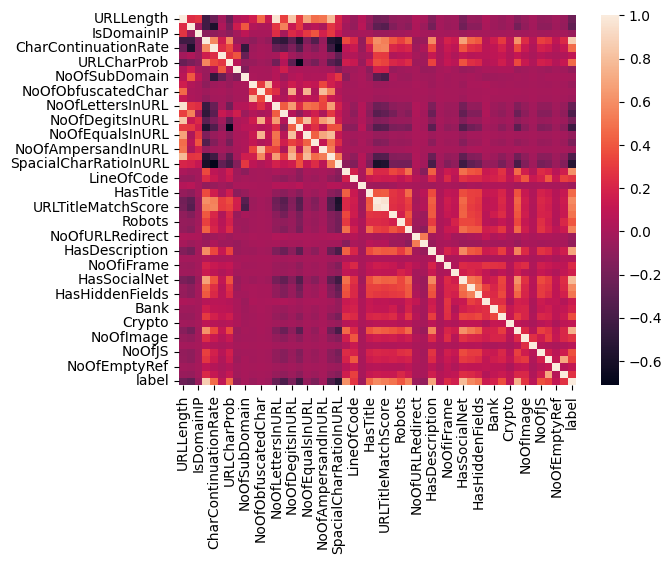

In [43]:
import seaborn as sns
sns.heatmap(df_numeric.corr())

In [44]:
df.select_dtypes(include='object').nunique()

FILENAME    235795
URL         235370
Domain      220086
TLD            695
Title       197874
dtype: int64

In [45]:
df = df.drop(columns= ['FILENAME'])

In [46]:
X = df.drop('label', axis=1)
y = df['label']

In [47]:
X = X.drop(columns= ['Domain','TLD','Title'])

In [48]:
y.value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify=y, random_state = 42)

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(analyzer= 'char', ngram_range= (3,5), max_features= 5000)

In [51]:
X_train_tfidf = tfidf.fit_transform(X_train['URL'])
X_test_tfidf = tfidf.fit_transform(X_test['URL'])

In [52]:
from scipy.sparse import hstack

X_train_num = X_train.drop(columns=['URL'])
X_test_num = X_test.drop(columns=['URL'])

X_train_final = hstack([X_train_tfidf, X_train_num])
X_test_final = hstack([X_test_tfidf, X_test_num])

In [53]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train_final, y_train)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [21:37:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The XGBClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [54]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test_final)
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test_final)[:,1]))


              precision    recall  f1-score   support

           0       0.43      1.00      0.60     20189
           1       0.00      0.00      0.00     26970

    accuracy                           0.43     47159
   macro avg       0.21      0.50      0.30     47159
weighted avg       0.18      0.43      0.26     47159

ROC AUC: 0.9999998365464896


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [55]:
probs = model.predict_proba(X_test_final)[:,1]
print(probs[:20])


[2.1540962e-02 2.1540962e-02 2.0499539e-02 2.0404601e-02 2.1540962e-02
 9.6279473e-06 2.1540962e-02 1.8204972e-02 2.1540962e-02 6.8270415e-06
 1.5370637e-02 6.8270415e-06 6.8270415e-06 1.1789399e-05 2.1540962e-02
 6.8270415e-06 2.1540962e-02 2.1540962e-02 2.1540962e-02 6.8270415e-06]


In [56]:
y_pred = (probs > 0.01).astype(int)


In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97     20189
           1       1.00      0.96      0.98     26970

    accuracy                           0.98     47159
   macro avg       0.97      0.98      0.97     47159
weighted avg       0.98      0.98      0.98     47159



In [58]:
import joblib

joblib.dump(model, "xgb_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save threshold
threshold = 0.01
joblib.dump(threshold, "threshold.pkl")


['threshold.pkl']

In [59]:
numeric_columns = X_train_num.columns.tolist()
joblib.dump(numeric_columns, "numeric_columns.pkl")


['numeric_columns.pkl']